<a href="https://colab.research.google.com/github/Aatka-Saleem/ML-Core-Implementations/blob/main/03-Classification-Models/NaiveBayesClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Naive Bayes (NB) is a probabilistic classifier based on Bayes’ theorem. It predicts the probability that a data point belongs to a class,assuming the features are independent given the class.


* “Naive” = the algorithm assumes features are independent (which may not be true in reality, but often works well).
*  “Bayes” = it uses Bayes’ theorem to calculate probabilities.






**Example**: If you’re identifying a fruit as an "Apple," the algorithm looks at "Red," "Round," and "3-inch diameter." It treats these as independent traits. In reality, a red round fruit is very likely to be a certain size, but Naive Bayes ignores those correlations to keep the math simple.

* C = a class (e.g., “spam” or “not spam”)
* x = feature vector (input data)
* P(C∣x) = probability of class C given features x (posterior)
* 𝑃(x∣C) = probability of features x given class C (likelihood)
* P(C) = probability of class C (prior)
* 𝑃(x)= probability of features x

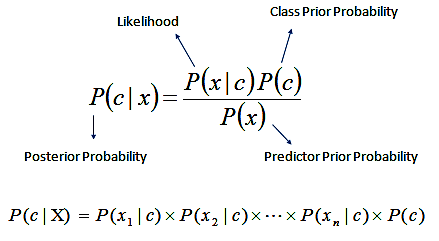

The key assumption is conditional independence:
* P(X∣C)=P(x1​,x2​,...,xn​∣C)≈P(x1​∣C)⋅P(x2​∣C)⋅...⋅P(xn​∣C)
* This simplifies computation a lot.
* Instead of calculating joint probabilities of all features (hard), we multiply probabilities of individual features given the class.

# Types of Naive Bayes

* Gaussian NB → assumes features are continuous and normally distributed.
* Multinomial NB → assumes features are counts (good for text, like word frequencies).
* Bernoulli NB → assumes binary features (0/1).

# Gaussian Naive Bayes

For continuous features, each feature 𝑥𝑖 is assumed to follow a Gaussian distribution in each class:

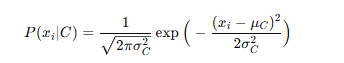

* 𝜇 = mean of the feature in class C
* σ = variance of the feature in class C


Then the likelihood for all features is:

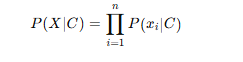

# Classification Rule
* Compute the posterior for each class:

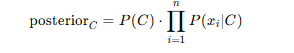

* Predict the class with the highest posterior:

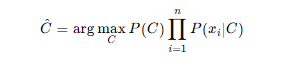

In practice, we take log to avoid underflow:

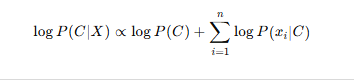

# Implementation of Gaussian Naive Bayes

In [ ]:
import numpy as np

class NaiveBayes:

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # calculate mean, var, and prior for each class
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)


    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        # calculate posterior probability for each class
        for idx, c in enumerate(self._classes):
            prior = np.log(self._priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = posterior + prior
            posteriors.append(posterior)

        # return class with the highest posterior
        return self._classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator


# Testing
if __name__ == "__main__":
    # Imports
    from sklearn.model_selection import train_test_split
    from sklearn import datasets

    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy

    X, y = datasets.make_classification(
        n_samples=1000, n_features=10, n_classes=2, random_state=123
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123
    )

    nb = NaiveBayes()
    nb.fit(X_train, y_train)
    predictions = nb.predict(X_test)

    print("Naive Bayes classification accuracy", accuracy(y_test, predictions))

Naive Bayes classification accuracy 0.965
